<a href="https://colab.research.google.com/github/zzzer0-wav/Melbourne_Housing/blob/main/notebooks/melbourbn_housing%20(group_notebook).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Проект Melbourne housing / group lesson

In [19]:
# import - це "підключити інструмент". "as" - дати йому коротке ім'я.
import numpy as np            # numpy: робота з числами
import pandas as pd           # pandas: таблиці (DataFrame)
import matplotlib.pyplot as plt   # matplotlib: графіки

# щоб результати щоразу були однакові, зафіксуйте випадковість
RANDOM_STATE = 42

### Крок 1. Завантаження даних


In [20]:
# 1) збережіть ваше RAW-посилання у змінну (у лапках)
RAW_URL = "https://raw.githubusercontent.com/KsiuTretyakova/melbourne-housing-DTA/refs/heads/main/data/melb_data.csv"

# 2) прочитайте CSV у таблицю df.
#    - у pandas є функція для читання CSV (її назва починається на read_)
#    - передайте їй RAW_URL
df = pd.read_csv(RAW_URL)

# 3) перевірте, що все завантажилось:
#    - надрукуйте df.shape  -> покаже (рядків, стовпців)
#    - викличте df.head()   -> покаже перші 5 рядків
print('size of dataset:', df.shape)
df.head()

size of dataset: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [22]:
df[['Suburb', 'Address', 'Type', 'Method', 'SellerG',
       'Date', 'CouncilArea', 'Regionname']].describe()

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,5 Margaret St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


In [23]:
# 3) пропуски: зробіть таблицю "скільки пропусків у кожному стовпці у відсотках"
#    - підказка: візьміть df.isna().mean(), помножте на 100, округліть
#    - відсортуйте від найбільшого до найменшого, щоб одразу побачити проблемні стовпці
# ...

print(f'Missing: {df.isna().sum().sum()} / {df.size}')

info = pd.DataFrame({
    'type':df.dtypes,
    'count_na':df.isna().sum(),
    '%_na':(df.isna().mean() * 100).round(2)
})

info.sort_values(['%_na', 'count_na'], ascending=False)

Missing: 13256 / 285180


,type,count_na,%_na
BuildingArea,float64,6450,47.50
YearBuilt,float64,5375,39.58
CouncilArea,object,1369,10.08
Car,float64,62,0.46
Suburb,object,0,0.00
Address,object,0,0.00
Rooms,int64,0,0.00
Type,object,0,0.00
Price,float64,0,0.00
Method,object,0,0.00


In [24]:
# 4) описова статистика чисел
#    - викличте df.describe()
#    - подивіться на рядки min і max: чи немає неможливих значень?
df.describe().round(1)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.0,13580.0,13580.0,13580.0,13580.0,13580.0,13518.0,13580.0,7130.0,8205.0,13580.0,13580.0,13580.0
mean,2.9,1075684.1,10.1,3105.3,2.9,1.5,1.6,558.4,152.0,1964.7,-37.8,145.0,7454.4
std,1.0,639310.7,5.9,90.7,1.0,0.7,1.0,3990.7,541.0,37.3,0.1,0.1,4378.6
min,1.0,85000.0,0.0,3000.0,0.0,0.0,0.0,0.0,0.0,1196.0,-38.2,144.4,249.0
25%,2.0,650000.0,6.1,3044.0,2.0,1.0,1.0,177.0,93.0,1940.0,-37.9,144.9,4380.0
50%,3.0,903000.0,9.2,3084.0,3.0,1.0,2.0,440.0,126.0,1970.0,-37.8,145.0,6555.0
75%,3.0,1330000.0,13.0,3148.0,3.0,2.0,2.0,651.0,174.0,1999.0,-37.8,145.1,10331.0
max,10.0,9000000.0,48.1,3977.0,20.0,8.0,10.0,433014.0,44515.0,2018.0,-37.4,145.5,21650.0


### Крок 3. Очищення

In [25]:
# зробіть копію, щоб не псувати оригінал
clean = df.copy()
# df_origin = df.copy()

# 1) приберіть технічний стовпець-індекс, якщо він є
#    - подивіться у список стовпців; знайдіть зайвий (схожий на номери рядків)
#    - приберіть його через clean.drop(columns=[...])
if clean.columns[0] == ['Unnamed: 0']:
  clean = clean.drop(columns=['Unnamed: 0'])

# 2) перетворіть стовпець Date на тип дати
#    - використайте pd.to_datetime(...)
#    - не забудьте підказати, що день іде першим (аргумент dayfirst)
clean['Date'] = pd.to_datetime(clean["Date"], dayfirst=True)

# 3) нулі-площі зробіть пропусками
#    - для відповідних стовпців (де нуль означає "немає даних")
#    - ідея: clean.loc[clean[стовпець] == 0, стовпець] = np.nan
for col in ['Landsize', 'BuildingArea']:
  clean.loc[clean[col] == 0, col] = np.nan

# 4) неможливий рік побудови -> пропуск
#    - оберіть розумну нижню межу року (наприклад, нижче неї значення - помилка)
#    - присвойте таким клітинкам np.nan
# ...

# 5) перевірте дублікати
#    - надрукуйте clean.duplicated().sum()
#    - якщо більше 0 - приберіть через clean.drop_duplicates()
clean.duplicated().sum()
clean.drop_duplicates()

# 6) гляньте розмір після чищення: clean.shape
clean.shape

(13580, 21)

### Крок 4. Дослідження (EDA)

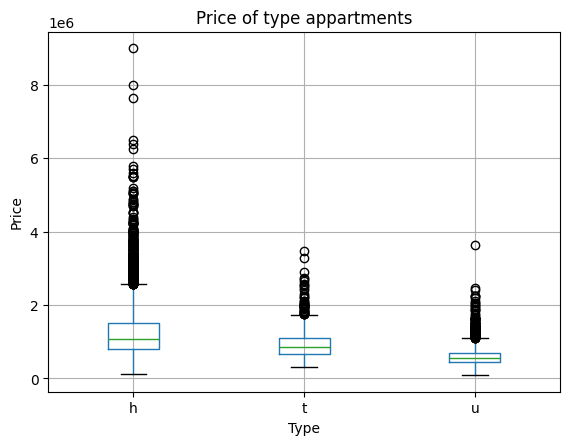

In [26]:
# 3) ціна за типом житла: boxplot
#    - підказка: clean.boxplot(column="Price", by="Type")
clean.boxplot(column="Price", by="Type")
plt.suptitle("")
plt.title("Price of type appartments")
plt.ylabel("Price")
plt.show()

In [27]:
# 4) кореляція числових ознак ІЗ ЦІНОЮ:
#    - візьміть лише числові стовпці: num = clean.select_dtypes("number")
#    - порахуйте num.corr()
#    - візьміть стовпець ["Price"], приберіть сам Price (.drop("Price"))
#    - відсортуйте за модулем: .sort_values(key=abs, ascending=False)
#    - надрукуйте і прочитайте: що найсильніше пов'язане з ціною?


num = clean.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

,Price
Rooms,0.497
Bedroom2,0.476
Bathroom,0.467
YearBuilt,-0.324
Car,0.239
Lattitude,-0.213
Longtitude,0.204
Distance,-0.163
Postcode,0.108
BuildingArea,0.092


In [28]:

df_drop = df.copy()
df_drop = df_drop.dropna()
print("before drop:", df.shape)
print("ater drop:", df_drop.shape)
num = df_drop.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
ater drop: (6196, 21)


,Price
Rooms,0.534
BuildingArea,0.531
Bedroom2,0.515
Bathroom,0.504
YearBuilt,-0.305
Car,0.262
Lattitude,-0.214
Longtitude,0.212
Distance,-0.149
Postcode,0.126


In [29]:
# 5) пошук майже-дублікатів: подивіться на повну матрицю кореляцій
#    - num.corr() (можна .round(2))
#    - знайдіть пари з дуже високим зв'язком (наприклад, Rooms і Bedroom2)
# ...

### Крок 5. Нові ознаки (feature engineering)

In [30]:
fe = clean.copy()

# 1) частини дати продажу
#    - рік: fe["sale_year"] = fe["Date"].dt.year
#    - місяць: за аналогією дістаньте .dt.month
fe["sale_year"] = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

# 2) вік будинку на момент продажу
#    - це рік продажу мінус рік побудови (YearBuilt)
#    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan
fe["age"] = fe["sale_year"] - fe['YearBuilt']
fe.loc[fe['age'] < 0, 'age'] = np.nan

# 3) прапорці наявності (пропуск як сигнал)
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"] = fe["YearBuilt"].notna().astype(int)

# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())

# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
drop_cols = [
    'Bedroom2', 'Address', 'Suburb', 'Postcode',
    'Date', 'YearBuilt', 'SellerG', 'BuildingArea'
]
fe = fe.drop(columns=drop_cols)
fe

,Rooms,Type,Price,Method,Distance,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,sale_year,sale_month,age,has_buildingarea,has_yearbuilt,suburb_freq
0,2,h,1480000.0,S,2.5,1.0,1.0,202.0,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0,2016,12,NaN,0,0,56
1,2,h,1035000.0,S,2.5,1.0,0.0,156.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0,2016,2,116.0,1,1,56
2,3,h,1465000.0,SP,2.5,2.0,0.0,134.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0,2017,3,117.0,1,1,56
3,3,h,850000.0,PI,2.5,2.0,1.0,94.0,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0,2017,3,NaN,0,0,56
4,4,h,1600000.0,VB,2.5,1.0,2.0,120.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0,2016,6,2.0,1,1,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,4,h,1245000.0,S,16.7,2.0,2.0,652.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0,2017,8,36.0,0,1,26
13576,3,h,1031000.0,SP,6.8,2.0,2.0,333.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0,2017,8,22.0,1,1,107
13577,3,h,1170000.0,S,6.8,2.0,4.0,436.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0,2017,8,20.0,0,1,107
13578,4,h,2500000.0,PI,6.8,1.0,5.0,866.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0,2017,8,97.0,1,1,107


### Крок 6. Підготовка до моделювання

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій

# 1) ціль і ознаки
#    - y = ціна (стовпець Price)
#    - X = усе інше (приберіть Price)
y = fe['Price']
X = fe.drop(columns=['Price'])


# 2) поділіть стовпці на категорійні і числові
#    - cat_cols = [...]   # текстові: Type, Method, Regionname, CouncilArea
#    - num_cols = [...]   # решта числових (усе, що не в cat_cols)
cat_cols = ['Type', 'Method', 'Regionname', 'CouncilArea']
num_cols = [c for c in X.columns if c not in cat_cols]

# 3) опишіть підготовку через ColumnTransformer:
#    - для числових: SimpleImputer(strategy="median")
#    - для категорійних: спочатку SimpleImputer(strategy="most_frequent"),
#      потім OneHotEncoder(handle_unknown="ignore")
#    - підказка щодо структури:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy='most_frequent')),
        ("ohe", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


# 4) поділіть дані на train і test
#    - використайте train_test_split з test_size=0.2 і random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Numeric features:", num_cols)
print("Categories features:", cat_cols)

Train: 10864 | Test: 2716
Numeric features: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Propertycount', 'sale_year', 'sale_month', 'age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']
Categories features: ['Type', 'Method', 'Regionname', 'CouncilArea']


### Крок 7. Модель і прогноз

In [14]:
from sklearn.dummy import DummyRegressor                 # базова лінія
from sklearn.linear_model import LinearRegression        # проста модель
from sklearn.ensemble import RandomForestRegressor       # складніша модель
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Зручно зробити невелику функцію, що навчає модель і друкує метрики:
def evaluate(model, name):
    # 1) склейте підготовку і модель у конвеєр:
    #    pipe = Pipeline([("prep", preprocess), ("model", model)])
    # 2) навчіть на ТРЕНУВАЛЬНИХ даних: pipe.fit(X_train, y_train)
    # 3) зробіть прогноз на ТЕСТОВИХ даних: pred = pipe.predict(X_test)
    # 4) порахуйте і надрукуйте MAE, RMSE (корінь із mean_squared_error), R2
    # 5) поверніть pipe (знадобиться далі)
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, {
        "model": name,
        "MAE": round(mean_absolute_error(y_test, pred)),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R2": round(r2_score(y_test, pred), 3)
    }

# Викличте evaluate по черзі:
#  - DummyRegressor(strategy="mean")            -> базова лінія
#  - LinearRegression()                         -> проста модель
#  - RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE) -> ліс
# Порівняйте результати: яка модель найкраща і чому?

_, r0 = evaluate(DummyRegressor(strategy="mean"), 'базова лінія (mean)')
_, r1 = evaluate(LinearRegression(), 'лінійна регресія')
rf_pipe, r2 = evaluate(
    RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Randon Forest'
)

pd.DataFrame([r0, r1, r2])

,model,MAE,RMSE,R2
0,базова лінія (mean),461258,630259,-0.000
1,лінійна регресія,260070,380284,0.636
2,Randon Forest,167778,275602,0.809


In [15]:
# Важливість ознак у лісу:
#  - у навченого лісу візьміть model.feature_importances_
#  - назви стовпців після One-Hot дістаньте через get_feature_names_out
#  - відсортуйте і подивіться топ ознак

ohe_names = rf_pipe.named_steps['prep'].named_transformers_['cat'] \
            .named_steps['ohe'].get_feature_names_out(cat_cols)

feat_names = list(num_cols) + list(ohe_names)
imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names) \
      .sort_values(ascending=False).head(15)

plt.figure(figsize=(5, 3))
imp[::-1].plot.barh()
plt.show()

imp.round(3)

### Прогноз (на автоматично заповнених даних)

In [32]:
example = X_test.iloc[[0]]
true_price = y_test.iloc[0]

pred_price = rf_pipe.predict(example)[0]

print(f'Прогноз: {pred_price:,.2f}')
print(f'Справжня ціна: {true_price:,.2f}')
print('-' * 10)
print(f'Error: {pred_price - true_price:,.2f}')
print(f'Error: {np.abs((pred_price - true_price) / true_price):,.2%}')

Прогноз: 2,368,945.00
Справжня ціна: 2,600,000.00
----------
Error: -231,055.00
Error: 8.89%


### Розбір from sklearn.impute import SimpleImputer

In [17]:
from sklearn.impute import SimpleImputer
import numpy as np

X = [[25], [30], [np.nan], [35]]

imputer = SimpleImputer(strategy='mean')  # for numeric
# imputer = SimpleImputer(strategy='median') # for numeric
# imputer = SimpleImputer(strategy='most_frequent') # mode
# imputer = SimpleImputer(strategy='constant', fill_value=10000) # own value
X_filled = imputer.fit_transform(X)
X_filled

array([[25.],
       [30.],
       [30.],
       [35.]])

### Розбір скорочених даних (менше 50%, проте наповнені оригінально)

In [18]:
df_drop = df.copy()
df_drop = df_drop.dropna()
print("before drop:", df.shape)
print("ater drop:", df_drop.shape)
num = df_drop.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
ater drop: (6196, 21)


,Price
Rooms,0.534
BuildingArea,0.531
Bedroom2,0.515
Bathroom,0.504
YearBuilt,-0.305
Car,0.262
Lattitude,-0.214
Longtitude,0.212
Distance,-0.149
Postcode,0.126


In [33]:
fe_drop = df_drop.copy()
fe_drop['Date'] = pd.to_datetime(fe_drop["Date"], dayfirst=True)

# 1) частини дати продажу
#    - рік: fe["sale_year"] = fe["Date"].dt.year
#    - місяць: за аналогією дістаньте .dt.month
fe_drop["sale_year"] = fe_drop["Date"].dt.year
fe_drop["sale_month"] = fe_drop["Date"].dt.month

# 2) вік будинку на момент продажу
#    - це рік продажу мінус рік побудови (YearBuilt)
#    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan
fe_drop["age"] = fe_drop["sale_year"] - fe_drop['YearBuilt']
fe_drop.loc[fe_drop['age'] < 0, 'age'] = np.nan

# 3) прапорці наявності (пропуск як сигнал)
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
fe_drop["has_buildingarea"] = fe_drop["BuildingArea"].notna().astype(int)
fe_drop["has_yearbuilt"] = fe_drop["YearBuilt"].notna().astype(int)

# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
fe_drop["suburb_freq"] = fe_drop["Suburb"].map(fe_drop["Suburb"].value_counts())

# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
drop_cols = [
    'Bedroom2', 'Address', 'Suburb', 'Postcode',
    'Date', 'YearBuilt', 'SellerG', #'BuildingArea'
]
fe_drop = fe_drop.drop(columns=drop_cols)
fe_drop

,Rooms,Type,Price,Method,Distance,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,sale_year,sale_month,age,has_buildingarea,has_yearbuilt,suburb_freq
1,2,h,1035000.0,S,2.5,1.0,0.0,156.0,79.00,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0,2016,2,116.0,1,1,36
2,3,h,1465000.0,SP,2.5,2.0,0.0,134.0,150.00,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0,2017,3,117.0,1,1,36
4,4,h,1600000.0,VB,2.5,1.0,2.0,120.0,142.00,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0,2016,6,2.0,1,1,36
6,3,h,1876000.0,S,2.5,2.0,0.0,245.0,210.00,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0,2016,5,106.0,1,1,36
7,2,h,1636000.0,S,2.5,1.0,2.0,256.0,107.00,Yarra,-37.80600,144.99540,Northern Metropolitan,4019.0,2016,10,126.0,1,1,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12205,3,h,601000.0,S,35.5,2.0,1.0,972.0,149.00,Whittlesea,-37.51232,145.13282,Northern Victoria,2170.0,2017,7,21.0,1,1,1
12206,3,h,1050000.0,VB,6.8,1.0,0.0,179.0,115.00,Hobsons Bay,-37.86558,144.90474,Western Metropolitan,6380.0,2017,7,127.0,1,1,50
12207,1,u,385000.0,SP,6.8,1.0,1.0,0.0,35.64,Hobsons Bay,-37.85588,144.89936,Western Metropolitan,6380.0,2017,7,50.0,1,1,50
12209,2,u,560000.0,PI,4.6,1.0,1.0,0.0,61.60,Stonnington,-37.85581,144.99025,Southern Metropolitan,4380.0,2017,7,5.0,1,1,26


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій

# 1) ціль і ознаки
#    - y = ціна (стовпець Price)
#    - X = усе інше (приберіть Price)
y = fe_drop['Price']
X = fe_drop.drop(columns=['Price'])


# 2) поділіть стовпці на категорійні і числові
#    - cat_cols = [...]   # текстові: Type, Method, Regionname, CouncilArea
#    - num_cols = [...]   # решта числових (усе, що не в cat_cols)
cat_cols = ['Type', 'Method', 'Regionname', 'CouncilArea']
num_cols = [c for c in X.columns if c not in cat_cols]

# 3) опишіть підготовку через ColumnTransformer:
#    - для числових: SimpleImputer(strategy="median")
#    - для категорійних: спочатку SimpleImputer(strategy="most_frequent"),
#      потім OneHotEncoder(handle_unknown="ignore")
#    - підказка щодо структури:
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy='most_frequent')),
        ("ohe", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


# 4) поділіть дані на train і test
#    - використайте train_test_split з test_size=0.2 і random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print("Numeric features:", num_cols)
print("Categories features:", cat_cols)

Train: 4956 | Test: 1240
Numeric features: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Lattitude', 'Longtitude', 'Propertycount', 'sale_year', 'sale_month', 'age', 'has_buildingarea', 'has_yearbuilt', 'suburb_freq']
Categories features: ['Type', 'Method', 'Regionname', 'CouncilArea']


In [35]:
from sklearn.dummy import DummyRegressor                 # базова лінія
from sklearn.linear_model import LinearRegression        # проста модель
from sklearn.ensemble import RandomForestRegressor       # складніша модель
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Зручно зробити невелику функцію, що навчає модель і друкує метрики:
def evaluate(model, name):
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return pipe, {
        "model": name,
        "MAE": round(mean_absolute_error(y_test, pred)),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R2": round(r2_score(y_test, pred), 3)
    }

# Викличте evaluate по черзі:
#  - DummyRegressor(strategy="mean")            -> базова лінія
#  - LinearRegression()                         -> проста модель
#  - RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE) -> ліс
# Порівняйте результати: яка модель найкраща і чому?

_, r0 = evaluate(DummyRegressor(strategy="mean"), 'базова лінія (mean)')
_, r1 = evaluate(LinearRegression(), 'лінійна регресія')
rf_pipe, r2 = evaluate(
    RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Randon Forest'
)

pd.DataFrame([r0, r1, r2])

,model,MAE,RMSE,R2
0,базова лінія (mean),481279,644880,-0.001
1,лінійна регресія,247047,347771,0.709
2,Randon Forest,166808,278612,0.813


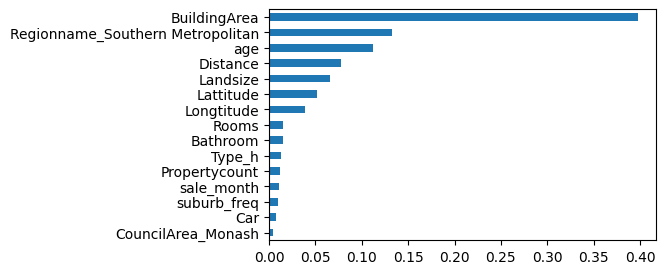

,0
BuildingArea,0.398
Regionname_Southern Metropolitan,0.132
age,0.112
Distance,0.078
Landsize,0.066
Lattitude,0.051
Longtitude,0.039
Rooms,0.016
Bathroom,0.015
Type_h,0.013


In [36]:
ohe_names = rf_pipe.named_steps['prep'].named_transformers_['cat'] \
            .named_steps['ohe'].get_feature_names_out(cat_cols)

feat_names = list(num_cols) + list(ohe_names)
imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names) \
      .sort_values(ascending=False).head(15)

plt.figure(figsize=(5, 3))
imp[::-1].plot.barh()
plt.show()

imp.round(3)

### Прогноз на скорочених даних

In [37]:
example = X_test.iloc[[0]]
true_price = y_test.iloc[0]

pred_price = rf_pipe.predict(example)[0]

print(f'Прогноз: {pred_price:,.2f}')
print(f'Справжня ціна: {true_price:,.2f}')
print('-' * 10)
print(f'Error: {pred_price - true_price:,.2f}')
print(f'Error: {np.abs((pred_price - true_price) / true_price):,.2%}')

Прогноз: 635,652.50
Справжня ціна: 660,000.00
----------
Error: -24,347.50
Error: 3.69%
